# Retail Sales Analysis
# Notebook 5 — Product Segmentation (Optional)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid')

product_features = pd.read_csv('product_features.csv')
print(f'product_features: {product_features.shape}')
display(product_features.head())

product_features: (452, 9)


,ProductID,product_name,category,price,total_quantity_sold,total_revenue,num_transactions,num_customers,avg_discount
0,1,Flour - Whole Wheat,Cereals,74.30,189516,13660696.25,14591,13536,0.03
1,2,Cookie Chocolate Chip With,Cereals,91.23,191914,16973050.83,14703,13648,0.03
2,3,Onions - Cippolini,Poultry,9.14,190799,1691427.12,14693,13680,0.03
3,4,"Sauce - Gravy, Au Jus, Mix",Poultry,54.31,193339,10190399.92,14908,13872,0.03
4,5,Artichokes - Jerusalem,Shell fish,65.48,192160,12203189.75,14790,13752,0.03


---
## 1. Подготовка признаков

In [2]:
PRODUCT_FEATURES = ['total_quantity_sold', 'total_revenue', 'num_transactions', 'num_customers']

product_seg_features = product_features[PRODUCT_FEATURES].copy().fillna(0)

scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_seg_features)

print('Признаки масштабированы')
display(product_seg_features.describe())

Признаки масштабированы


,total_quantity_sold,total_revenue,num_transactions,num_customers
count,452.00,452.00,452.00,452.00
mean,192485.72,9489473.07,14802.21,13747.96
std,1690.39,5346982.63,112.74,98.82
min,187817.00,8435.93,14513.00,13485.00
25%,191373.25,4941015.62,14721.75,13679.75
50%,192491.50,9772801.76,14799.50,13748.00
75%,193581.00,14213309.82,14881.00,13810.00
max,197807.00,18702819.49,15215.00,14130.00


---
## 2. Elbow Method

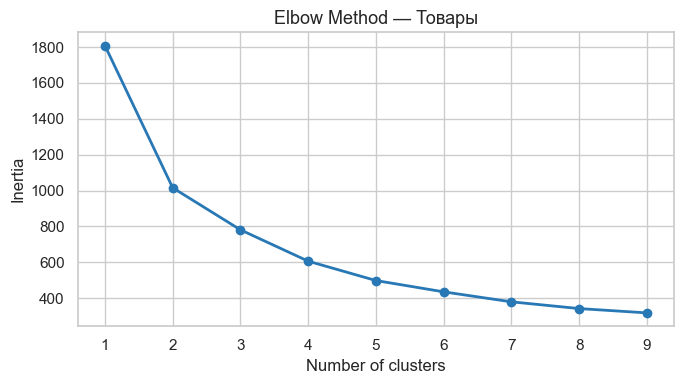

In [3]:
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(product_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 10), inertia, marker='o', color='#2878b5', linewidth=2)
plt.title('Elbow Method — Товары', fontsize=13)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

---
## 3. Кластеризация + названия сегментов

In [4]:
N_PRODUCT_CLUSTERS = 4

product_kmeans = KMeans(n_clusters=N_PRODUCT_CLUSTERS, random_state=42, n_init=10)
product_features['product_cluster'] = product_kmeans.fit_predict(product_scaled)

product_cluster_summary = (
    product_features
    .groupby('product_cluster')[PRODUCT_FEATURES]
    .mean().round(2)
)
product_cluster_summary['count'] = product_features['product_cluster'].value_counts().sort_index()

print('Средние по кластерам товаров:')
display(product_cluster_summary)

Средние по кластерам товаров:


,total_quantity_sold,total_revenue,num_transactions,num_customers,count
product_cluster,,,,,
0,194422.13,11934192.80,14938.79,13866.23,115
1,190385.87,6244059.72,14658.18,13620.95,84
2,191915.19,14155732.02,14761.21,13715.81,129
3,192705.89,4566283.93,14815.77,13757.77,124


In [5]:
product_segment_names = {
    0: 'Popular products',
    1: 'Mid-performing products',
    2: 'High revenue products',
    3: 'Low performing products'
}

product_features['product_segment'] = product_features['product_cluster'].map(product_segment_names)

display(
    product_features[['ProductID','product_name','category',
                       'total_revenue','num_customers','product_segment']]
    .sort_values('total_revenue', ascending=False).head(15).reset_index(drop=True)
)

,ProductID,product_name,category,total_revenue,num_customers,product_segment
0,345,Bread - Calabrese Baguette,Dairy,18702819.49,13870,Popular products
1,98,Shrimp - 31/40,Cereals,18522350.93,13682,High revenue products
2,392,Puree - Passion Fruit,Beverages,18521965.85,13789,High revenue products
3,104,Tia Maria,Beverages,18497276.26,13861,Popular products
4,149,Zucchini - Yellow,Snails,18368011.96,13703,High revenue products
5,268,Vanilla Beans,Poultry,18333954.17,13811,Popular products
6,201,Grenadine,Grain,18152871.70,13833,Popular products
7,248,Beef - Inside Round,Meat,18140322.53,13623,Mid-performing products
8,32,Lettuce - Treviso,Cereals,18127274.82,13844,Popular products
9,298,Pop Shoppe Cream Soda,Dairy,18026323.89,13897,Popular products


---
## 4. Визуализация

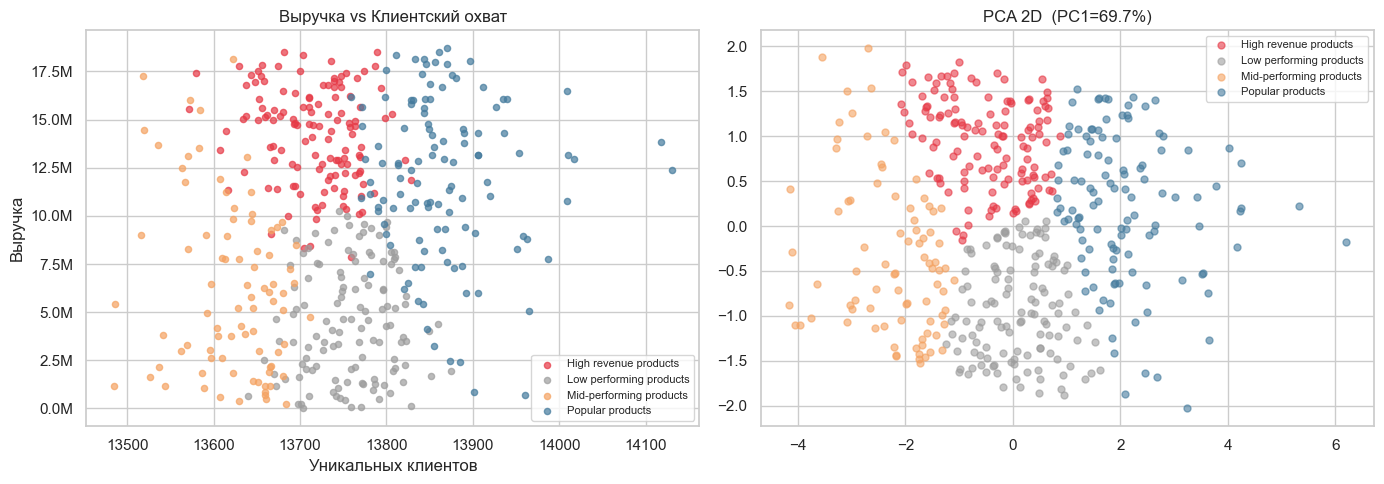

In [ ]:
palette = {
    'High revenue products': '#e63946',   
    'Popular products': '#457b9d',       
    'Mid-performing products': '#f4a261', 
    'Low performing products': '#9d9d9d'  
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for seg, grp in product_features.groupby('product_segment'):
    axes[0].scatter(grp['num_customers'], grp['total_revenue'],
                    label=seg, s=20, alpha=0.7, color=palette.get(seg, 'grey'))
axes[0].set_xlabel('Уникальных клиентов')
axes[0].set_ylabel('Выручка')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_title('Выручка vs Клиентский охват', fontsize=12)
axes[0].legend(fontsize=8)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(product_scaled)
pca_df = pd.DataFrame(coords, columns=['PC1','PC2'])
pca_df['segment'] = product_features['product_segment'].values
for seg, grp in pca_df.groupby('segment'):
    axes[1].scatter(grp['PC1'], grp['PC2'], label=seg, s=25, alpha=0.6,
                    color=palette.get(seg, 'grey'))
axes[1].set_title(f'PCA 2D  (PC1={pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Сохранение

In [9]:
product_features.to_csv('product_segments.csv', index=False)
product_cluster_summary.to_csv('product_cluster_summary.csv')
print('Сохранены: product_segments.csv, product_cluster_summary.csv')

Сохранены: product_segments.csv, product_cluster_summary.csv


## Интерпретация сегментов

| Сегмент | Бизнес-смысл | Действие |
|---------|-------------|----------|
| **High revenue products** | Лидеры по выручке | Приоритет в наличии, промо-фокус |
| **Popular mass products** | Широкий охват, высокий спрос | Оптимизировать поставки |
| **Niche products** | Узкая лояльная аудитория | Кросс-сейл с популярными товарами |
| **Low performing products** | Низкий спрос | Промо или вывод из ассортимента |